In [7]:
!pip install -q wordcloud scikit-learn nltk pandas matplotlib seaborn datasets

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import re
import string
import warnings
warnings.filterwarnings('ignore')

# NLTK downloads
import nltk
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk import ngrams
nltk.download('punkt_tab', quiet=True)

from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns

print(' Setup complete!')

 Setup complete!


## Part A: Chargement du Dataset 20 Newsgroups

In [2]:
# Charger le dataset depuis sklearn
from sklearn.datasets import fetch_20newsgroups

# Charger l'ensemble d'entraînement
newsgroups = fetch_20newsgroups(
    subset='train',
    remove=('headers', 'footers', 'quotes'),
    shuffle=True,
    random_state=42
)

# Créer un DataFrame
df = pd.DataFrame({
    'text': newsgroups.data,
    'label': newsgroups.target,
    'label_text': [newsgroups.target_names[i] for i in newsgroups.target]
})

print(f'Dataset shape: {df.shape}')
print(f'\nColumns: {df.columns.tolist()}')
print(f'\nLabel distribution:')
print(df['label_text'].value_counts())

Dataset shape: (11314, 3)

Columns: ['text', 'label', 'label_text']

Label distribution:
label_text
rec.sport.hockey            600
soc.religion.christian      599
rec.motorcycles             598
rec.sport.baseball          597
sci.crypt                   595
rec.autos                   594
sci.med                     594
comp.windows.x              593
sci.space                   593
comp.os.ms-windows.misc     591
sci.electronics             591
comp.sys.ibm.pc.hardware    590
misc.forsale                585
comp.graphics               584
comp.sys.mac.hardware       578
talk.politics.mideast       564
talk.politics.guns          546
alt.atheism                 480
talk.politics.misc          465
talk.religion.misc          377
Name: count, dtype: int64


In [3]:
# Voir un exemple
print('Sample document:')
print('='*50)
print(f"Label: {df.iloc[0]['label_text']}")
print(f"Text (first 500 chars): {df.iloc[0]['text'][:500]}...")

Sample document:
Label: rec.autos
Text (first 500 chars): I was wondering if anyone out there could enlighten me on this car I saw
the other day. It was a 2-door sports car, looked to be from the late 60s/
early 70s. It was called a Bricklin. The doors were really small. In addition,
the front bumper was separate from the rest of the body. This is 
all I know. If anyone can tellme a model name, engine specs, years
of production, where this car is made, history, or whatever info you
have on this funky looking car, please e-mail....


### Exercise A.1: Sélectionner 3 catégories intéressantes

In [4]:
# SOLUTION: Choisir 3 catégories variées et intéressantes
my_categories = ['rec.sport.hockey', 'sci.med', 'talk.politics.guns']

# Filtrer le dataset
df_filtered = df[df['label_text'].isin(my_categories)].copy()
df_filtered = df_filtered.reset_index(drop=True)

print(f'Selected categories: {my_categories}')
print(f'Filtered dataset size: {len(df_filtered)}')
print(f'\nDistribution:')
print(df_filtered['label_text'].value_counts())

Selected categories: ['rec.sport.hockey', 'sci.med', 'talk.politics.guns']
Filtered dataset size: 1740

Distribution:
label_text
rec.sport.hockey      600
sci.med               594
talk.politics.guns    546
Name: count, dtype: int64


## Part B: Text Preprocessing

### Fonction de Preprocessing Avancée

In [8]:
# SOLUTION: Fonction de preprocessing complète
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text_advanced(text):
    """
    Advanced text preprocessing with stop words removal and lemmatization.
    """
    # Step 1: Lowercase
    text = text.lower()
    
    # Step 2: Remove emails
    text = re.sub(r'\S+@\S+', '', text)
    
    # Step 3: Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    
    # Step 4: Remove numbers
    text = re.sub(r'\d+', '', text)
    
    # Step 5: Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    # Step 6: Remove extra whitespace
    text = ' '.join(text.split())
    
    # Step 7: Tokenize
    tokens = word_tokenize(text)
    
    # Step 8: Remove stop words
    tokens = [t for t in tokens if t not in stop_words]
    
    # Step 9: Lemmatize
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    
    # Step 10: Remove short words (< 3 chars)
    tokens = [t for t in tokens if len(t) >= 3]
    
    # Step 11: Join back
    return ' '.join(tokens)

# Test
sample = "The cats are running quickly towards the beautiful gardens. Email: test@mail.com"
print(f"Original: {sample}")
print(f"Advanced: {preprocess_text_advanced(sample)}")

Original: The cats are running quickly towards the beautiful gardens. Email: test@mail.com
Advanced: cat running quickly towards beautiful garden email


In [9]:
# Appliquer le preprocessing (peut prendre quelques minutes)
print('Preprocessing in progress...')
df_filtered['text_clean'] = df_filtered['text'].apply(preprocess_text_advanced)
print(f'Preprocessing complete!')

# Exemple
print("\nSample preprocessed document:")
print(df_filtered.iloc[0]['text_clean'][:300])

Preprocessing in progress...
Preprocessing complete!

Sample preprocessed document:
course term must rigidly defined bill doubt term using quote allegedly back read article presenting first argument weapon mass destruction commonly understood switching topic first point evidently show weapon allowed later analysis given understanding consider another class


## Part C: Text Visualization

### C.1 Bar Charts: Top Words per Category

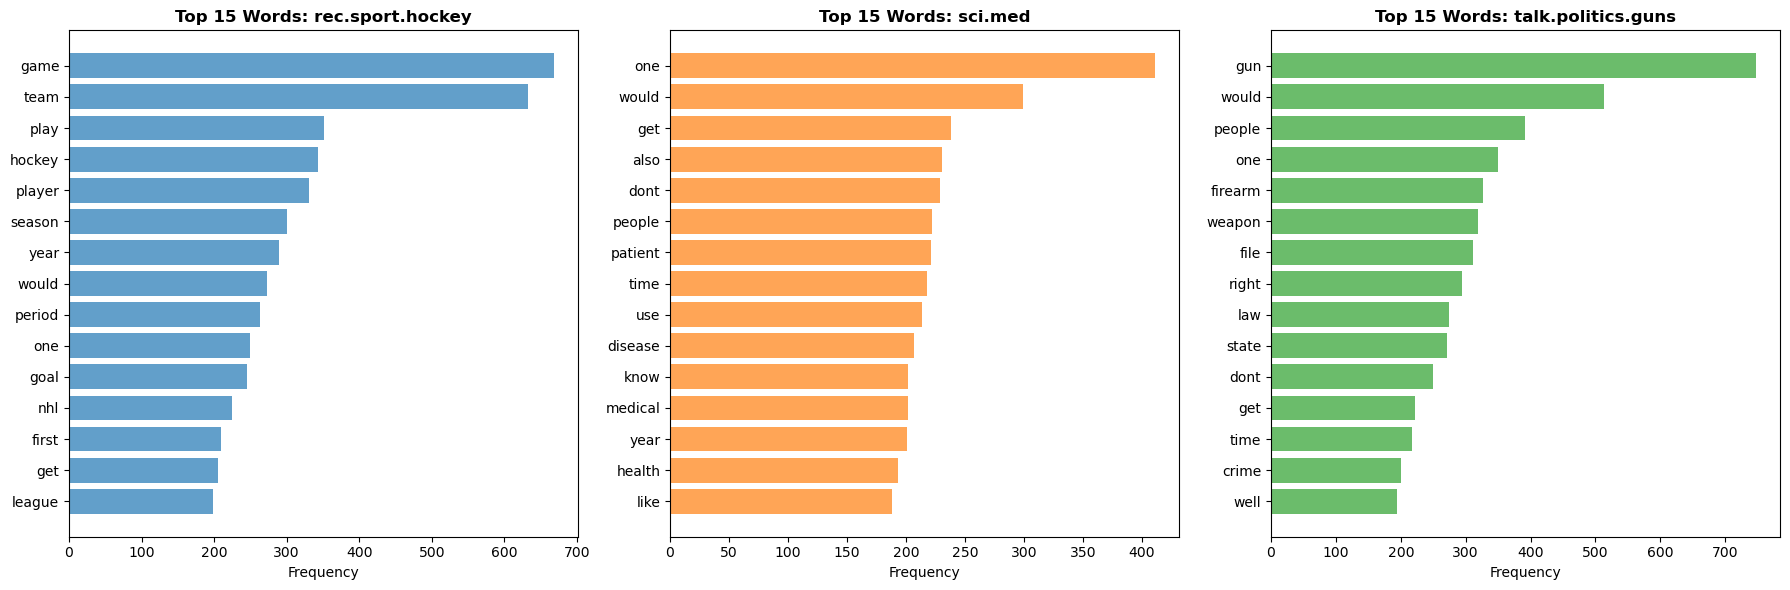

 Bar charts saved!


In [10]:
# SOLUTION: Fonction pour obtenir les top mots
def get_top_words(texts, n=15):
    """Get the n most common words from a list of texts."""
    all_words = ' '.join(texts).split()
    word_counts = Counter(all_words)
    return word_counts.most_common(n)

# Get top words for each category
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

for idx, category in enumerate(my_categories):
    texts = df_filtered[df_filtered['label_text'] == category]['text_clean'].tolist()
    top_words = get_top_words(texts, 15)
    
    words, counts = zip(*top_words)
    axes[idx].barh(words, counts, color=colors[idx], alpha=0.7)
    axes[idx].set_title(f'Top 15 Words: {category}', fontsize=12, fontweight='bold')
    axes[idx].invert_yaxis()
    axes[idx].set_xlabel('Frequency')

plt.tight_layout()
plt.savefig('top_words_by_category.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Bar charts saved!')

### C.2 Word Clouds

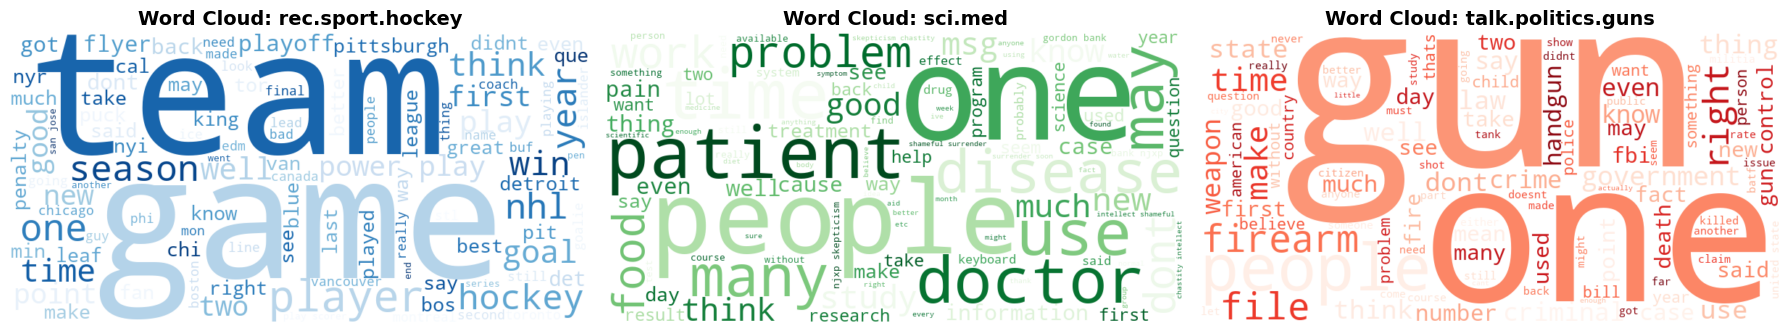

 Word clouds saved!


In [11]:
# SOLUTION: Word clouds pour chaque catégorie
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
colors = ['Blues', 'Greens', 'Reds']

for idx, category in enumerate(my_categories):
    texts = df_filtered[df_filtered['label_text'] == category]['text_clean'].tolist()
    text_combined = ' '.join(texts)
    
    wordcloud = WordCloud(
        width=800, 
        height=400,
        background_color='white',
        colormap=colors[idx],
        max_words=100,
        min_font_size=10
    ).generate(text_combined)
    
    axes[idx].imshow(wordcloud, interpolation='bilinear')
    axes[idx].set_title(f'Word Cloud: {category}', fontsize=14, fontweight='bold')
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('wordclouds_by_category.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Word clouds saved!')

### C.3 Custom Circular Word Cloud

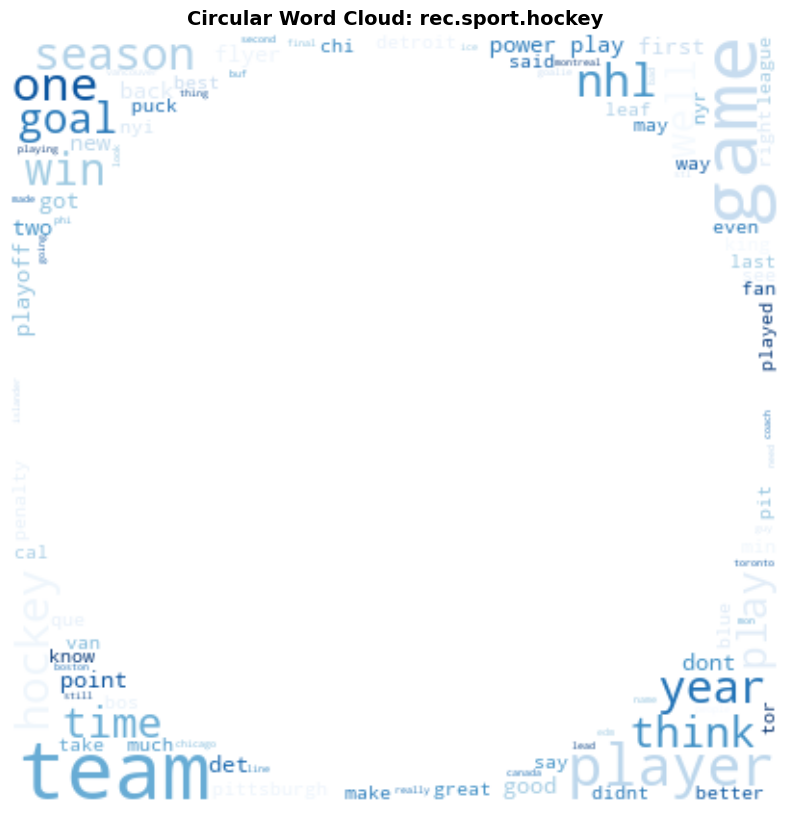

 Custom word cloud saved!


In [12]:
#  SOLUTION: Créer un mask circulaire
from PIL import Image

def create_circle_mask(size=400):
    """Create a circular mask."""
    x = np.arange(0, size)
    y = np.arange(0, size)
    cx, cy = size // 2, size // 2
    r = size // 2 - 10
    mask = np.zeros((size, size), dtype=np.uint8)
    for i in x:
        for j in y:
            if (i - cx)**2 + (j - cy)**2 <= r**2:
                mask[j, i] = 255
    return mask

circle_mask = create_circle_mask(400)

# Créer word cloud avec mask pour la première catégorie
category_for_mask = my_categories[0]
texts = df_filtered[df_filtered['label_text'] == category_for_mask]['text_clean'].tolist()
text_combined = ' '.join(texts)

wordcloud_masked = WordCloud(
    width=400,
    height=400,
    background_color='white',
    mask=circle_mask,
    colormap='Blues',
    max_words=150
).generate(text_combined)

plt.figure(figsize=(10, 10))
plt.imshow(wordcloud_masked, interpolation='bilinear')
plt.title(f'Circular Word Cloud: {category_for_mask}', fontsize=14, fontweight='bold')
plt.axis('off')
plt.savefig('custom_wordcloud.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Custom word cloud saved!')

## Part D: Bag of Words (BoW) Representation

In [13]:
# SOLUTION: BoW avec bons paramètres
bow_vectorizer = CountVectorizer(
    max_features=1000,
    min_df=5,
    max_df=0.95
)

bow_matrix = bow_vectorizer.fit_transform(df_filtered['text_clean'])

print(f'BoW Matrix shape: {bow_matrix.shape}')
print(f'Vocabulary size: {len(bow_vectorizer.get_feature_names_out())}')
print(f'\nFirst 20 words in vocabulary: {bow_vectorizer.get_feature_names_out()[:20]}')

BoW Matrix shape: (1740, 1000)
Vocabulary size: 1000

First 20 words in vocabulary: ['abc' 'able' 'accident' 'according' 'acid' 'acquired' 'act' 'action'
 'activity' 'actually' 'adam' 'add' 'addition' 'address' 'adult'
 'advantage' 'age' 'agency' 'agent' 'ago']


### Exercise D.1: Document Similarity with BoW

In [14]:
# SOLUTION: Calcul de similarité cosinus
# Compute similarity matrix
similarity_matrix = cosine_similarity(bow_matrix)

# Find the 2 most similar documents (excluding self-similarity)
np.fill_diagonal(similarity_matrix, -1)  # Ignore self-similarity

# Get the highest similarity score and its indices
max_similarity_idx = np.unravel_index(similarity_matrix.argmax(), similarity_matrix.shape)
max_similarity_score = similarity_matrix[max_similarity_idx]

print(f'Most similar documents: {max_similarity_idx}')
print(f'Similarity score: {max_similarity_score:.4f}')
print(f'\nDocument 1 category: {df_filtered.iloc[max_similarity_idx[0]]["label_text"]}')
print(f'Document 2 category: {df_filtered.iloc[max_similarity_idx[1]]["label_text"]}')

Most similar documents: (np.int64(848), np.int64(1064))
Similarity score: 1.0000

Document 1 category: rec.sport.hockey
Document 2 category: rec.sport.hockey


In [15]:
# Show the similar documents
print('\n' + '='*60)
print('Document 1 (first 300 chars):')
print('='*60)
print(df_filtered.iloc[max_similarity_idx[0]]['text'][:300])

print('\n' + '='*60)
print('Document 2 (first 300 chars):')
print('='*60)
print(df_filtered.iloc[max_similarity_idx[1]]['text'][:300])


Document 1 (first 300 chars):
Here is the price list for the week April 13 to April 19.

	- Andrew

Buy	Sell	Pts	Team	Player
158.9	143.0	157	PIT	Mario_Lemieux
148.5	133.7	145	BUF	Pat_LaFontaine
142.7	128.4	141	BOS	Adam_Oates
137.6	123.8	136	DET	Steve_Yzerman
132.1	118.9	129	WPG	Teemu_Selanne
131.7	118.5	127	NYI	Pierre_Turgeon
13

Document 2 (first 300 chars):
Here is the price list for the week April 6 to April 12.

	- Andrew

Buy	Sell	Pts	Team	Player
157.5	141.8	150	PIT	Mario_Lemieux
152.1	136.9	143	BUF	Pat_LaFontaine
139.3	125.4	131	BOS	Adam_Oates
133.8	120.4	129	DET	Steve_Yzerman
132.9	119.6	125	WPG	Teemu_Selanne
132.9	119.6	125	TOR	Doug_Gilmour
130.9


## Part E: TF-IDF Representation

In [16]:
#  SOLUTION: TF-IDF vectorizer
tfidf_vectorizer = TfidfVectorizer(
    max_features=1000,
    min_df=5,
    max_df=0.95
)

tfidf_matrix = tfidf_vectorizer.fit_transform(df_filtered['text_clean'])

print(f'TF-IDF Matrix shape: {tfidf_matrix.shape}')

TF-IDF Matrix shape: (1740, 1000)


In [17]:
# SOLUTION: Top TF-IDF words pour chaque catégorie
def get_top_tfidf_words(category, tfidf_matrix, vectorizer, df_filtered, n=10):
    """Get top n words by average TF-IDF score for a category."""
    # Get indices of documents in this category
    cat_indices = df_filtered[df_filtered['label_text'] == category].index.tolist()
    
    # Get their TF-IDF vectors
    cat_tfidf = tfidf_matrix[cat_indices]
    
    # Compute mean TF-IDF for each word
    mean_tfidf = np.asarray(cat_tfidf.mean(axis=0)).ravel()
    
    # Get feature names
    feature_names = vectorizer.get_feature_names_out()
    
    # Get top words
    top_indices = np.argsort(mean_tfidf)[::-1][:n]
    top_words = [(feature_names[i], mean_tfidf[i]) for i in top_indices]
    
    return top_words

# Display top words for each category
print('Top TF-IDF Words by Category:')
print('='*60)
for category in my_categories:
    top_words = get_top_tfidf_words(category, tfidf_matrix, tfidf_vectorizer, df_filtered, 10)
    print(f"\n{category}:")
    for word, score in top_words:
        print(f"  {word}: {score:.4f}")

Top TF-IDF Words by Category:

rec.sport.hockey:
  game: 0.0732
  team: 0.0617
  player: 0.0431
  hockey: 0.0410
  play: 0.0322
  year: 0.0301
  season: 0.0300
  would: 0.0287
  nhl: 0.0263
  playoff: 0.0257

sci.med:
  one: 0.0337
  know: 0.0301
  msg: 0.0300
  would: 0.0281
  patient: 0.0277
  food: 0.0274
  dont: 0.0274
  disease: 0.0272
  gordon: 0.0271
  doctor: 0.0270

talk.politics.guns:
  gun: 0.0669
  would: 0.0478
  people: 0.0390
  weapon: 0.0367
  right: 0.0332
  dont: 0.0317
  law: 0.0299
  one: 0.0291
  government: 0.0288
  firearm: 0.0260


## Part F: N-grams and Next Word Prediction

In [18]:
#  SOLUTION: Analyser les bigrams
def get_top_ngrams(texts, n=2, top_k=15):
    """Get top ngrams from texts."""
    all_ngrams = []
    for text in texts:
        tokens = text.split()
        ngram_list = list(ngrams(tokens, n))
        all_ngrams.extend(ngram_list)
    
    ngram_counts = Counter(all_ngrams)
    return ngram_counts.most_common(top_k)

# Find top bigrams for each category
print('Top Bigrams by Category:')
print('='*60)
for category in my_categories:
    texts = df_filtered[df_filtered['label_text'] == category]['text_clean'].tolist()
    top_bigrams = get_top_ngrams(texts, n=2, top_k=10)
    
    print(f"\n{category}:")
    for bigram, count in top_bigrams:
        print(f"  {' '.join(bigram)}: {count}")

Top Bigrams by Category:

rec.sport.hockey:
  power play: 138
  play scorer: 63
  san jose: 62
  third period: 58
  second period: 56
  first period: 53
  los angeles: 52
  hockey league: 52
  new jersey: 51
  tampa bay: 50

sci.med:
  gordon bank: 80
  bank njxp: 73
  njxp skepticism: 73
  skepticism chastity: 73
  chastity intellect: 73
  intellect shameful: 72
  shameful surrender: 72
  surrender soon: 72
  medical newsletter: 55
  volume number: 54

talk.politics.guns:
  gun control: 110
  united state: 72
  second amendment: 56
  dont know: 34
  military weapon: 33
  dont think: 32
  waiting period: 32
  bear arm: 30
  assault weapon: 30
  gun owner: 29


### Exercise F.1: Simple Next Word Predictor

In [19]:
# SOLUTION: Classe de prédiction
class SimpleNextWordPredictor:
    def __init__(self):
        self.bigram_counts = {}  # {word1: {word2: count, ...}}
        self.unigram_counts = {}  # {word: count}
    
    def train(self, texts):
        """Train the model on a list of texts."""
        for text in texts:
            tokens = text.split()
            
            # Count unigrams
            for token in tokens:
                self.unigram_counts[token] = self.unigram_counts.get(token, 0) + 1
            
            # Count bigrams
            for i in range(len(tokens) - 1):
                word1 = tokens[i]
                word2 = tokens[i + 1]
                
                if word1 not in self.bigram_counts:
                    self.bigram_counts[word1] = {}
                
                self.bigram_counts[word1][word2] = \
                    self.bigram_counts[word1].get(word2, 0) + 1
    
    def predict_next(self, word, top_n=5):
        """Predict the most likely next words given a word."""
        word = word.lower()
        
        if word not in self.bigram_counts:
            return []
        
        next_words = self.bigram_counts[word]
        total_count = sum(next_words.values())
        
        # Calculate probabilities
        predictions = [
            (w, count / total_count) 
            for w, count in next_words.items()
        ]
        
        # Sort by probability and return top N
        predictions.sort(key=lambda x: x[1], reverse=True)
        return predictions[:top_n]

# Train the predictor
print('Training next word predictor...')
predictor = SimpleNextWordPredictor()
predictor.train(df_filtered['text_clean'].tolist())
print(' Training complete!')

Training next word predictor...
 Training complete!


In [20]:
# SOLUTION: Tester le prédicteur avec des mots pertinents
test_words = ['team', 'medical', 'law', 'player', 'disease']

print('Next Word Predictions:')
print('='*60)

for word in test_words:
    predictions = predictor.predict_next(word, top_n=5)
    print(f"\n'{word}' ->") 
    if predictions:
        for next_word, prob in predictions:
            print(f"  {next_word}: {prob:.3f}")
    else:
        print("  [No predictions]")

Next Word Predictions:

'team' ->
  would: 0.023
  top: 0.016
  play: 0.014
  record: 0.014
  captain: 0.014

'medical' ->
  newsletter: 0.249
  school: 0.054
  center: 0.050
  problem: 0.045
  education: 0.032

'law' ->
  enforcement: 0.097
  state: 0.033
  abiding: 0.023
  passed: 0.020
  effect: 0.017

'player' ->
  team: 0.033
  like: 0.027
  play: 0.021
  moncton: 0.018
  nhl: 0.015

'disease' ->
  control: 0.051
  prevention: 0.028
  would: 0.019
  national: 0.019
  strike: 0.019


## Part G: Document Similarity Heatmap

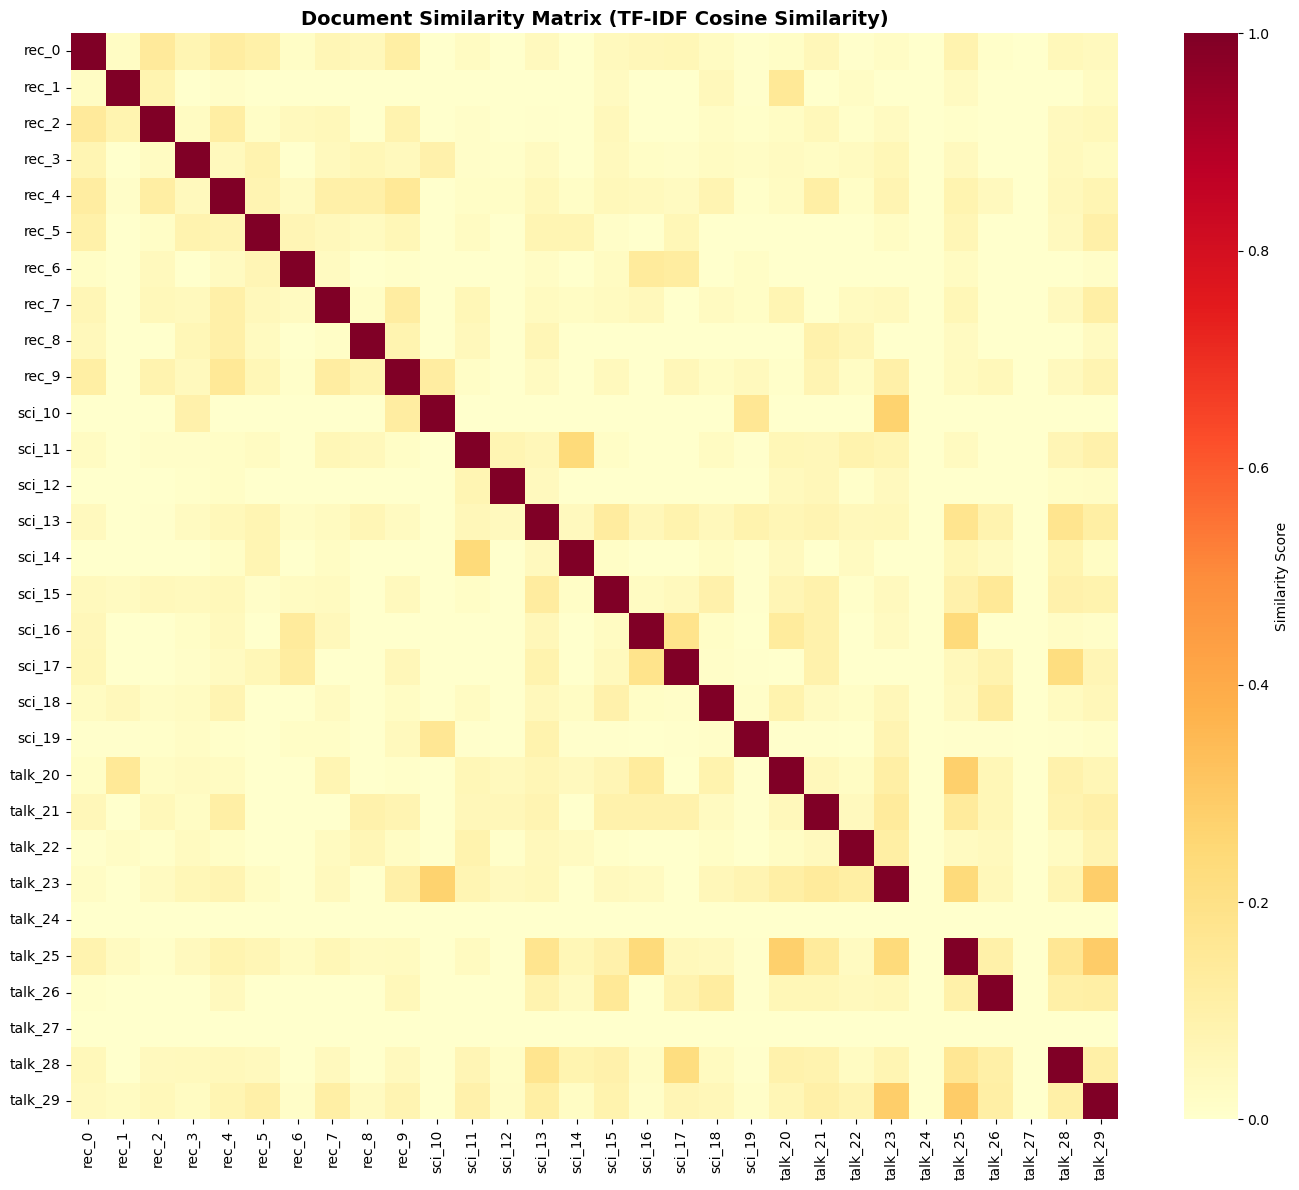

Similarity heatmap saved!


In [21]:
# SOLUTION: Créer une matrice de similarité pour un sample
# Sample 10 documents from each category
sampled_dfs = []
for category in my_categories:
    cat_df = df_filtered[df_filtered['label_text'] == category].sample(
        n=min(10, len(df_filtered[df_filtered['label_text'] == category])), 
        random_state=42
    )
    sampled_dfs.append(cat_df)

df_sampled = pd.concat(sampled_dfs).reset_index(drop=True)

# Create TF-IDF for sampled documents
tfidf_sampled_vec = TfidfVectorizer(max_features=500)
tfidf_sampled = tfidf_sampled_vec.fit_transform(df_sampled['text_clean'])

# Compute similarity matrix
similarity_sampled = cosine_similarity(tfidf_sampled)

# Create labels
labels = [f"{df_sampled.iloc[i]['label_text'].split('.')[0]}_{i}" 
          for i in range(len(df_sampled))]

# Plot heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(
    similarity_sampled,
    xticklabels=labels,
    yticklabels=labels,
    cmap='YlOrRd',
    annot=False,
    cbar_kws={'label': 'Similarity Score'}
)
plt.title('Document Similarity Matrix (TF-IDF Cosine Similarity)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('document_similarity_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Similarity heatmap saved!')